# Playbook Atelier 2 : Parties 5 à 9 (venv-data)

Parties en Markdown, cellules de code, interprétation sous chaque cellule ; noyau **Python (venv-data)**. Les cellules « Étape manuelle » créent automatiquement les fichiers que les apprenants créent dans l'Explorateur.

# PARTIE 5 : LE DEUXIÈME ENVIRONNEMENT VIRTUEL

Les Parties 1 à 4 ont tourné dans `.venv-base` (Python pur, NumPy). Les parties suivantes (pandas, graphiques) vivent dans un environnement **séparé**, `.venv-data`. Cette partie montre pourquoi.

## 🛠️ Créer `.venv-data`

Ouvrir un **deuxième** terminal dans `formation_python_fabric` (le premier fait tourner Jupyter, on ne l'arrête pas).

```powershell
py -m venv .venv-data
.venv-data\Scripts\activate.bat
py -m pip install --upgrade pip
py -m pip install pandas matplotlib seaborn pyarrow ipykernel
py -m pip freeze > requirements-data.txt
py -m ipykernel install --user --name venv-data --display-name "Python (venv-data)"
```

```text
Installed kernelspec venv-data in C:\Users\formation\AppData\Roaming\jupyter\kernels\venv-data
```

| Paquet       | Rôle                                                                          |
| ------------ | ----------------------------------------------------------------------------- |
| `pandas`     | Tableaux de données (DataFrame) ; installe **NumPy** avec lui                 |
| `matplotlib` | Graphiques de base                                                            |
| `seaborn`    | Graphiques statistiques, construits sur matplotlib et pandas                  |
| `pyarrow`    | Lecture et écriture du format **Parquet** (celui de Fabric)                   |
| `ipykernel`  | Permet à Jupyter d'utiliser cet environnement comme **noyau**                 |

**Ce que vous devez voir à l'écran** :

- l'invite du deuxième terminal préfixée par `(.venv-data)`
- `requirements-data.txt` créé (nettement plus long que `requirements-base.txt`)
- le message `Installed kernelspec venv-data ...`

## 🔍 La démonstration en quatre temps

**Temps 1 : rester dans `venv-base`.** Le notebook `atelier2` utilise encore le noyau **Python (venv-base)**. Exécuter les Cellules 32 et 33 ci-dessous : pandas est introuvable.

**Temps 2 : passer à `venv-data`.**

- Recharger la page du notebook (F5) si `venv-data` n'apparaît pas dans la liste.
- Menu **Kernel → Change kernel → Python (venv-data)**.
- Ré-exécuter les Cellules 32 et 33 : tout est présent.

**Temps 3 : revenir à `venv-base`.** **Kernel → Change kernel → Python (venv-base)**, puis ré-exécuter la Cellule 33 : l'erreur **revient**. Les bibliothèques n'ont pas disparu : elles n'ont jamais été dans cet environnement.

**Temps 4 : repartir sur `venv-data`** pour toute la suite de l'atelier.

| Situation                                    | Résultat de `import pandas`     |
| -------------------------------------------- | ------------------------------- |
| Noyau **venv-base**                          | `ModuleNotFoundError`           |
| Noyau **venv-data**                          | Fonctionne                      |
| Retour sur **venv-base**                     | `ModuleNotFoundError` à nouveau |

> ⚠️ **Changer de noyau efface les variables** du notebook (nouveau processus). Toutes les cellules des Parties 6 à 9 rechargent leurs données pour cette raison.

> 💡 **Le même principe dans Fabric** : deux **Environments** peuvent contenir des bibliothèques différentes, et chaque notebook choisit le sien. Un notebook sans l'Environment adéquat échoue avec la même `ModuleNotFoundError`.

## 📝 Cellule 32 : Contrôle des bibliothèques disponibles

In [1]:
# === CELLULE 32 : Ce que voit le noyau actif ===
import importlib.metadata as metadata      # versions des paquets installés
import sys
from importlib.util import find_spec       # teste la présence d'un paquet sans l'importer

# --- 1. Quel Python exécute cette cellule ?
print("Interpréteur :", sys.executable)

# --- 2. Pour chaque paquet : absent, ou sa version
for nom in ("numpy", "pandas", "matplotlib", "seaborn", "pyarrow"):
    if find_spec(nom) is None:                        # None = introuvable dans cet environnement
        print(f"{nom:<11} ABSENT")
    else:
        print(f"{nom:<11} {metadata.version(nom)}")

Interpréteur : C:\Users\formation\formation_python_fabric\.venv-data\Scripts\python.exe
numpy       2.5.3
pandas      3.0.6
matplotlib  3.11.2
seaborn     0.13.2
pyarrow     25.0.1


### 💡 Interprétation : Cellule 32, Contrôle des bibliothèques disponibles

- **Noyau `venv-base`** : NumPy est présent ; pandas, matplotlib, seaborn et pyarrow sont **absents**.
- **Même machine, même dossier** : c'est l'**environnement** qui décide, pas le poste.
- **Suite** : la cellule suivante montre l'erreur que produirait un `import pandas`.

## 📝 Cellule 33 : Importer pandas : l'erreur, puis la réussite

In [2]:
# === CELLULE 33 : Importer les bibliothèques de données ===
import numpy as np                       # calcul sur tableaux
import pandas as pd                      # tableaux de données (DataFrame)
import matplotlib                        # graphiques : bibliothèque de base
import matplotlib.pyplot as plt          # son interface de dessin
import seaborn as sns                    # graphiques statistiques

print("pandas", pd.__version__, "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | matplotlib 3.11.2 | seaborn 0.13.2


### 💡 Interprétation : Cellule 33, Importer pandas : l'erreur, puis la réussite

- **Dans `venv-base`** : `ModuleNotFoundError: No module named 'pandas'`. Le code est correct, c'est l'environnement qui est incomplet.
- **Dans `venv-data`** : les versions s'affichent.
- **Mauvais réflexe** : lancer `pip install pandas` dans `venv-base` ; on perdrait la séparation.
- **Bon réflexe** : choisir le bon noyau, et vérifier `sys.executable`.

## 📝 Cellule 34 : Lire le fichier CSV avec `read_csv`

In [3]:
# === CELLULE 34 : read_csv ===
from pathlib import Path

df = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig")   # lecture, BOM retiré
print(df.shape)                       # (nombre de lignes, nombre de colonnes)
print(df.columns.tolist())            # noms des colonnes
print(df.head(4))                     # aperçu des 4 premières lignes

(4365, 6)
['timestamp', 'site_id', 'consumption_mw', 'voltage_v', 'frequency_hz', 'status']
             timestamp       site_id  consumption_mw  voltage_v  frequency_hz  \
0  2025-01-30T03:00:00  SITE_COM_001           0.479      223.3         50.02   
1  2025-01-08 18:00:00  SITE_COM_001           1.288      229.1         49.95   
2  2025-01-30T16:00:00  SITE_COM_001           1.218      233.6         49.96   
3  2025-01-12T17:00:00  SITE_COM_002           0.672      230.2         49.83   

  status  
0     OK  
1     OK  
2     OK  
3     OK  


### 💡 Interprétation : Cellule 34, Lire le fichier CSV avec `read_csv`

- **`(4365, 6)`** : 4 365 lignes, 6 colonnes.
- **Types déduits** : `consumption_mw` est en `float64` (les vides deviennent `NaN`) ; avec le module `csv`, tout restait du texte.
- **`timestamp` encore en texte** : trois formats mélangés, à convertir (Partie 6).
- **`encoding="utf-8-sig"`** : à déclarer systématiquement pour les CSV Windows.

## 📝 Cellule 35 : Explorer : `info`, `dtypes`, `describe`

In [4]:
# === CELLULE 35 : Explorer le DataFrame ===
df.info()                                              # structure du tableau
print()
print(df["consumption_mw"].describe().round(3))        # statistiques de la colonne de consommation
print(df["status"].value_counts())                     # répartition des statuts

<class 'pandas.DataFrame'>
RangeIndex: 4365 entries, 0 to 4364
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       4365 non-null   str    
 1   site_id         4365 non-null   str    
 2   consumption_mw  4275 non-null   float64
 3   voltage_v       4365 non-null   float64
 4   frequency_hz    4365 non-null   float64
 5   status          4365 non-null   str    
dtypes: float64(3), str(3)
memory usage: 346.4 KB

count    4275.000
mean      -54.830
std       219.226
min      -999.000
25%         0.324
50%         0.531
75%         1.326
max         5.846
Name: consumption_mw, dtype: float64
status
OK       4012
ERROR     353
Name: count, dtype: int64


### 💡 Interprétation : Cellule 35, Explorer : `info`, `dtypes`, `describe`

- **`consumption_mw`** : 4 275 valeurs non nulles sur 4 365, donc **90 vides**.
- **Type `str`** : depuis pandas 3, les colonnes texte ont ce type ; en pandas 2.x, c'était `object`.
- **Statistiques faussées** : minimum `-999` et moyenne `-54,8` : les **codes erreur** sont comptés comme des mesures.
- **`status`** : 353 lignes `ERROR` (doublons compris).

## 📝 Cellule 36 : `Series`, `loc` et `iloc`

In [5]:
# === CELLULE 36 : Séries, loc et iloc ===
s = df["consumption_mw"]                              # une colonne = une Series
print(type(s).__name__, s.dtype, len(s))              # type de l'objet, type des valeurs, nombre de valeurs

print(df.loc[0, "site_id"], "|", df.iloc[0, 1])       # même case : par étiquette, puis par position
print(df.iloc[0:3, 1:3])                              # lignes 0 à 2, colonnes 1 et 2
print(df.loc[df["site_id"] == "SITE_IND_001", "consumption_mw"].head(3).tolist())   # masque + colonne

# Les mêmes syntaxes que sur le Tableau de la Partie 3
print(len(df), "site_id" in df, list(df)[:3])         # __len__, __contains__, __iter__ (noms de colonnes)
print(df.site_id.equals(df["site_id"]))               # __getattr__ : df.site_id est df["site_id"]

Series float64 4365
SITE_COM_001 | SITE_COM_001
        site_id  consumption_mw
0  SITE_COM_001           0.479
1  SITE_COM_001           1.288
2  SITE_COM_001           1.218
[2.874, 1.769, 1.595]
4365 True ['timestamp', 'site_id', 'consumption_mw']
True


### 💡 Interprétation : Cellule 36, `Series`, `loc` et `iloc`

- **`type` = `Series`** : une colonne, 4 365 valeurs `float64`.
- **`loc` et `iloc`** : étiquette `0` et position `0` coïncident ici, car l'index est `0, 1, 2…`.
- **Tranche `iloc[0:3, 1:3]`** : borne de fin **exclue** ; avec `loc`, la borne de fin est **incluse**.
- **`loc[masque, "colonne"]`** : forme standard pour lire un sous-ensemble.
- **`4365 True ['timestamp', 'site_id', 'consumption_mw']`** : `len`, `in` et `list(df)` se comportent comme sur le `Tableau`.
- **`True`** : `df.site_id` et `df["site_id"]` désignent la même colonne.

## 📝 Cellule 37 : Filtrer : masques, `isin`, `between`, `query`

In [6]:
# === CELLULE 37 : Filtres ===
fort = df[df["consumption_mw"] > 3.5]                 # lignes au-dessus de 3,5 MW
print(len(fort), fort["site_id"].unique().tolist())   # combien, et de quels sites

# Deux conditions : parenthèses obligatoires autour de chacune
masque = (df["site_id"] == "SITE_IND_002") & (df["consumption_mw"] > 3.5)
print(masque.sum())                                   # True compte pour 1

print(df["site_id"].isin(["SITE_RES_001", "SITE_RES_002"]).sum())   # lignes des deux sites résidentiels
print(df["consumption_mw"].between(1, 2).sum())                     # mesures entre 1 et 2 MW

# La même sélection que « masque », écrite avec query
print(len(df.query("site_id == 'SITE_IND_002' and consumption_mw > 3.5")))

6 ['SITE_COM_001', 'SITE_IND_002']
5
1454
1064
5


### 💡 Interprétation : Cellule 37, Filtrer : masques, `isin`, `between`, `query`

- **6 valeurs > 3,5 MW** : des pics de `SITE_COM_001` (capacité 2 MW) et `SITE_IND_002`.
- **Parenthèses obligatoires** autour de chaque condition avec `&` et `|`.
- **`isin`** : 1 454 lignes résidentielles ; **`between`** : bornes **incluses** par défaut.
- **`query`** : même résultat (5 lignes), plus lisible pour des conditions simples.

## 📝 Cellule 38 : Nouvelles colonnes : `assign`, `rename`, copie indépendante

In [7]:
# === CELLULE 38 : Colonnes, renommage, Copy-on-Write ===

# --- 1. Renommer une colonne (nom plus court)
df = df.rename(columns={"consumption_mw": "conso_mw"})

# --- 2. Ajouter une colonne « famille » : le 2e morceau de site_id (SITE_IND_001 -> IND)
df = df.assign(famille=lambda d: d["site_id"].str.split("_").str[1])      # d = le DataFrame en cours
print(df["famille"].value_counts().to_dict())

# --- 3. Copy-on-Write : on ajoute une colonne à un DataFrame dérivé ; l'original reste intact
sous = df[df["site_id"] == "SITE_IND_001"]                                # un sous-ensemble
sous = sous.assign(conso_kw=sous["conso_mw"] * 1000)                      # nouvelle colonne, en kW
print("colonne conso_kw dans df :", "conso_kw" in df.columns, "| dans sous :", "conso_kw" in sous.columns)

# --- 4. Modifier des lignes précises : ici, aucune valeur ne dépasse 100
df.loc[df["conso_mw"] > 100, "conso_mw"] = np.nan
print(df["conso_mw"].max())

{'COM': 1457, 'RES': 1454, 'IND': 1454}
colonne conso_kw dans df : False | dans sous : True
5.846


### 💡 Interprétation : Cellule 38, Nouvelles colonnes : `assign`, `rename`, copie indépendante

- **`assign`** : renvoie un **nouveau** DataFrame, sans modifier l'ancien.
- **Copy-on-Write (pandas 3)** : `conso_kw` n'existe que dans `sous`, jamais dans `df`.
- **Avant pandas 3** : écrire dans un sous-ensemble pouvait modifier l'original ou lever `SettingWithCopyWarning`.
- **`.loc[masque, "col"] = valeur`** : la bonne écriture ; ici aucune ligne ne dépasse 100. **Éviter `inplace`**.

## 📝 Cellule 39 : Types : `astype`, `category`, `to_numeric`

In [8]:
# === CELLULE 39 : Types et mémoire ===

# --- 1. Convertir en « category » les colonnes à peu de valeurs distinctes, et mesurer le gain
avant = df.memory_usage(deep=True).sum()                 # mémoire avant conversion (textes compris)
df["site_id"] = df["site_id"].astype("category")         # 6 valeurs distinctes sur 4 365 lignes
df["famille"] = df["famille"].astype("category")         # 3 valeurs distinctes
apres = df.memory_usage(deep=True).sum()                 # mémoire après conversion
print(f"{avant / 1024:.0f} Ko -> {apres / 1024:.0f} Ko")
print(df.dtypes)                                         # les nouveaux types

# --- 2. Convertir du texte en nombres : ce qui est illisible devient NaN au lieu de faire échouer
texte = pd.Series(["0.865", "abc", "", "1.2"])
print(pd.to_numeric(texte, errors="coerce").tolist())

568 Ko -> 270 Ko
timestamp            str
site_id         category
conso_mw         float64
voltage_v        float64
frequency_hz     float64
status               str
famille         category
dtype: object
[0.865, nan, nan, 1.2]


### 💡 Interprétation : Cellule 39, Types : `astype`, `category`, `to_numeric`

- **Environ 570 Ko → 270 Ko** (la valeur exacte varie selon la version de Python) : `category` stocke les 6 valeurs une fois, puis des codes entiers.
- **À réserver** aux colonnes à peu de valeurs distinctes.
- **`to_numeric(errors="coerce")`** : `'abc'` et `''` deviennent `NaN` au lieu de faire échouer la conversion.

# PARTIE 6 : LA QUALITÉ DES DONNÉES AVEC PANDAS

## 📝 Cellule 40 : Codes erreur : `isin`, `mask`, `replace`

In [9]:
# === CELLULE 40 : Codes erreur en NaN ===
CODES = [-999, -888, -777]

# Compter avant de nettoyer
print(df["conso_mw"].isin(CODES).sum(), "codes erreur")
print(df.loc[df["conso_mw"].isin(CODES), "conso_mw"].value_counts().to_dict())

# Deux écritures du même nettoyage
nettoye = df["conso_mw"].mask(df["conso_mw"].isin(CODES))     # NaN là où la valeur est un code
equivalent = df["conso_mw"].replace(CODES, np.nan)            # remplace chaque code par NaN
print(nettoye.isna().sum(), nettoye.equals(equivalent))       # nombre de NaN, résultats identiques ?
print(nettoye.min(), nettoye.max())                           # plus aucune valeur négative

263 codes erreur
{-999.0: 111, -888.0: 85, -777.0: 67}
353 True
0.216 5.846


### 💡 Interprétation : Cellule 40, Codes erreur : `isin`, `mask`, `replace`

- **263 lignes** avec un code : `-999` × 111, `-888` × 85, `-777` × 67 (doublons compris).
- **`mask` et `replace`** : résultats identiques (`True`) ; 353 `NaN` = 263 codes + 90 vides.
- **Après nettoyage** : minimum 0,216 ; plus aucune valeur négative.
- **Le maximum 5,846** reste un pic aberrant : il sera traité par le taux de charge.

## 📝 Cellule 41 : Doublons : `duplicated` et `drop_duplicates`

In [10]:
# === CELLULE 41 : Doublons ===
print(df.duplicated().sum(), "doublons exacts")                                        # ligne entière identique
print(df.duplicated(subset=["timestamp", "site_id"]).sum(), "doublons sur (timestamp, site)")   # même instant, même site

# Afficher les deux copies de quelques doublons (keep=False marque toutes les copies)
exemple = df[df.duplicated(keep=False)].sort_values(["site_id", "timestamp"]).head(4)
print(exemple[["timestamp", "site_id", "conso_mw"]])

sans_doublons = df.drop_duplicates()                   # on garde la première copie
print(len(df), "->", len(sans_doublons))

45 doublons exacts
45 doublons sur (timestamp, site)
                timestamp       site_id  conso_mw
125   13/01/2025 01:00:00  SITE_COM_001     0.544
3971  13/01/2025 01:00:00  SITE_COM_001     0.544
2506  2025-01-03T11:00:00  SITE_COM_001     1.398
2798  2025-01-03T11:00:00  SITE_COM_001     1.398
4365 -> 4320


### 💡 Interprétation : Cellule 41, Doublons : `duplicated` et `drop_duplicates`

- **45 doublons** : identiques sur toute la ligne **et** sur (`timestamp`, `site_id`) ; aucun conflit de valeur.
- **`keep=False`** : affiche les deux copies ; **`drop_duplicates()`** garde la première : 4 365 → 4 320 (6 × 720).
- **Texte brut** : deux écritures d'un même instant (`T` et `/`) ne seraient **pas** des doublons exacts.

## 📝 Cellule 42 : Dates : `to_datetime`, formats multiples, `dt`

In [11]:
# === CELLULE 42 : Dates ===

# --- 1. Les trois formats présents dans le fichier
FORMATS = ["%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S"]

# --- 2. Convertir : on essaie chaque format, et on garde ce qui a réussi
def parser_dates(serie):
    resultat = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[us]")     # départ : que des NaT (dates absentes)
    for fmt in FORMATS:
        # to_datetime avec errors="coerce" donne NaT quand le format ne correspond pas ;
        # fillna garde ce qui est déjà converti et complète le reste
        resultat = resultat.fillna(pd.to_datetime(serie, format=fmt, errors="coerce"))
    return resultat

# --- 3. Vérifier : type obtenu, dates illisibles, période couverte
ts = parser_dates(sans_doublons["timestamp"])
print(ts.dtype, ts.isna().sum(), "dates illisibles")
print(ts.min(), "->", ts.max())

# --- 4. Le piège : « mixed » devine chaque date seule, souvent à tort ; on compte les écarts avec notre résultat
brut_txt = sans_doublons["timestamp"]
mixte = pd.to_datetime(brut_txt, format="mixed")                        # sans indication
mixte_fr = pd.to_datetime(brut_txt, format="mixed", dayfirst=True)      # en privilégiant le jour en premier
print("mixed              : dates fausses =", int((mixte != ts).sum()))
print("mixed + dayfirst   : dates fausses =", int((mixte_fr != ts).sum()))

datetime64[us] 0 dates illisibles
2025-01-01 00:00:00 -> 2025-01-30 23:00:00


mixed              : dates fausses = 231
mixed + dayfirst   : dates fausses = 1353


### 💡 Interprétation : Cellule 42, Dates : `to_datetime`, formats multiples, `dt`

- **`datetime64[us]`** : 0 date illisible ; du 1er janvier 00:00 au 30 janvier 23:00. L'unité `us` est celle de pandas 3 (avant : `ns`).
- **Piège `format="mixed"`** : **231** dates fausses (`05/01/2025` lue comme le 1er mai).
- **Avec `dayfirst=True`** (pandas 3.0.6) : **1 353** dates fausses (`2025-01-08` lue comme le 1er août). **Aucun avertissement.** En pandas 2.2, ce même appel donne 0 erreur : le comportement change selon la version.
- **Règle** : formats explicites, `errors="coerce"`, puis compter les `NaT`.

## 📝 Cellule 43 : L'accesseur `.dt` et les fuseaux horaires

In [12]:
# === CELLULE 43 : Accesseur .dt et fuseaux ===
print(ts.dt.hour.head(3).tolist(), ts.dt.day_name().head(3).tolist())   # heure et nom du jour, sans boucle
print(ts.dt.dayofweek.value_counts().sort_index().to_dict())              # nombre de lignes par jour de semaine

utc = ts.dt.tz_localize("UTC")                        # les dates sont déclarées en UTC
paris = utc.dt.tz_convert("Europe/Paris")             # mêmes instants, vus à Paris
print(utc.iloc[0], "->", paris.iloc[0])
print(paris.dt.hour.iloc[0] - utc.dt.hour.iloc[0])    # décalage en heures (hiver : 1)

[3, 18, 16] ['Thursday', 'Wednesday', 'Thursday']
{0: 576, 1: 576, 2: 720, 3: 720, 4: 576, 5: 576, 6: 576}
2025-01-30 03:00:00+00:00 -> 2025-01-30 04:00:00+01:00
1


### 💡 Interprétation : Cellule 43, L'accesseur `.dt` et les fuseaux horaires

- **`.dt`** : heure, jour de semaine, sans boucle ; 720 lignes le mercredi et le jeudi (5 de chaque en janvier 2025), 576 les autres jours.
- **`tz_localize("UTC")` puis `tz_convert`** : `03:00 UTC` devient `04:00+01:00` à Paris (heure d'hiver).
- **`tzdata`** : installé automatiquement avec pandas ; aucun `%pip install` nécessaire ici.

## 📝 Cellule 44 : Chaînes : l'accesseur `.str`

In [13]:
# === CELLULE 44 : Chaînes ===
ids = pd.Series(sans_doublons["site_id"].astype(str).unique())     # les 6 identifiants distincts
print(ids.str.replace("SITE_", "", regex=False).tolist())          # enlève le préfixe
print(ids.str.contains("IND").tolist())                            # quels sites sont industriels ?
print(ids.str.extract(r"SITE_(?P<famille>[A-Z]{3})_(?P<numero>\d+)"))   # deux colonnes : famille, numero

['COM_001', 'COM_002', 'RES_002', 'IND_002', 'IND_001', 'RES_001']
[False, False, False, True, True, False]
  famille numero
0     COM    001
1     COM    002
2     RES    002
3     IND    002
4     IND    001
5     RES    001


### 💡 Interprétation : Cellule 44, Chaînes : l'accesseur `.str`

- **`replace(..., regex=False)`** : remplacement simple, sans expression régulière.
- **`contains("IND")`** : masque booléen (`True` pour les deux sites industriels).
- **`extract` avec groupes nommés** : `(?P<famille>...)` devient le nom de la colonne.

## 📝 Cellule 45 : Valeurs manquantes : compter et remplacer

In [14]:
# === CELLULE 45 : Manquants ===

# --- 1. DataFrame de travail : sans doublons, dates converties, codes remplacés par NaN
propre = sans_doublons.assign(timestamp=ts, conso_mw=nettoye[sans_doublons.index])
propre = propre.sort_values(["site_id", "timestamp"], ignore_index=True)     # tri par site puis par date

# --- 2. Compter les manquants : au total, puis en pourcentage par site
print(propre["conso_mw"].isna().sum(), "manquants au total")
print((propre.groupby("site_id", observed=True)["conso_mw"].apply(lambda s: s.isna().mean()) * 100).round(1).to_dict())

# --- 3. L'ancienne écriture : erreur en pandas 3, simple avertissement en pandas 2
import warnings
try:
    with warnings.catch_warnings():
        warnings.simplefilter("error")                 # un avertissement devient une erreur : même comportement dans les deux versions
        propre["conso_mw"].fillna(method="ffill")
except (TypeError, FutureWarning) as erreur:
    print(type(erreur).__name__, ":", str(erreur).split(". ")[0])

# --- 4. Comblement par interpolation, site par site (jamais d'un site à l'autre), trous de 3 heures maximum
comble = propre.groupby("site_id", observed=True)["conso_mw"].transform(lambda s: s.interpolate(limit=3))
print(propre["conso_mw"].isna().sum(), "->", comble.isna().sum())     # manquants avant -> après

350 manquants au total
{'SITE_COM_001': 9.2, 'SITE_COM_002': 7.1, 'SITE_IND_001': 6.9, 'SITE_IND_002': 8.6, 'SITE_RES_001': 10.1, 'SITE_RES_002': 6.7}
TypeError : NDFrame.fillna() got an unexpected keyword argument 'method'
350 -> 0


### 💡 Interprétation : Cellule 45, Valeurs manquantes : compter et remplacer

- **350 manquants** (8,1 %), de 6,7 % à 10,1 % selon le site : les mêmes chiffres qu'avec NumPy.
- **`fillna(method=...)`** : `TypeError` en pandas 3, `FutureWarning` en pandas 2.2 (rendu visible par `warnings.simplefilter("error")`) ; dans les deux cas, on écrit `.ffill()` ou `.bfill()`.
- **`interpolate(limit=3)` par site** : les 350 trous sont comblés (aucun trou de plus de 3 heures).
- **Décision métier** : combler ou non se décide avec le métier ; `propre` conserve les `NaN`.

## 📝 Cellule 46 : Un nettoyage lisible avec `pipe` et une fonction

In [15]:
# === CELLULE 46 : Fonction de nettoyage ===

# --- 1. Toutes les étapes dans une fonction : une étape par ligne, dans l'ordre
def nettoyer(brut: pd.DataFrame) -> pd.DataFrame:
    return (
        brut
        .drop_duplicates()                                                   # 1. doublons exacts
        .assign(
            timestamp=lambda d: parser_dates(d["timestamp"]),                # 2. dates converties (d = DataFrame en cours)
            conso_mw=lambda d: d["conso_mw"].mask(d["conso_mw"].isin(CODES)),   # 3. codes erreur -> NaN
        )
        .sort_values(["site_id", "timestamp"], ignore_index=True)            # 4. tri par site puis date
    )

# --- 2. On repart du fichier brut pour prouver que la fonction fait tout
brut = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
propre = brut.pipe(nettoyer)                     # pipe : équivaut à nettoyer(brut)

# --- 3. Contrôler le résultat
print(len(brut), "->", len(propre), "lignes")                                                   # doublons retirés
print(propre["conso_mw"].isna().sum(), "manquants,", propre["timestamp"].isna().sum(), "dates illisibles")
print(propre.dtypes)                                                                            # types corrects ?

4365 -> 4320 lignes
350 manquants, 0 dates illisibles
timestamp       datetime64[us]
site_id                    str
conso_mw               float64
voltage_v              float64
frequency_hz           float64
status                     str
dtype: object


### 💡 Interprétation : Cellule 46, Un nettoyage lisible avec `pipe` et une fonction

- **4 365 → 4 320 lignes**, 350 `NaN`, 0 date illisible.
- **Types corrects** : `timestamp` en `datetime64`, `conso_mw` en `float64`.
- **Rejouable** : la fonction `nettoyer` s'applique telle quelle au fichier du mois suivant.
- **`pipe`** : insère une fonction dans une chaîne d'opérations.

## 📝 Cellule 47 : Vérifier avec le module de l'Atelier 1

In [16]:
# === CELLULE 47 : Comparaison avec analyse_sites.py ===
from analyse_sites import analyser                     # le script de l'Atelier 1, importé comme un module

# --- 1. Résultat de l'Atelier 1 (boucles Python) : taux d'anomalies par site
rapport = analyser(Path("data/consommation_30jours.csv"), Path("data/sites_reference.csv"))
ref = {s: v["taux_anomalies"] for s, v in rapport["sites"].items()}    # dictionnaire {site: taux}

# --- 2. Résultat pandas : proportion de NaN par site (un NaN = une mesure invalide ou manquante)
taux = propre.groupby("site_id", observed=True)["conso_mw"].apply(lambda s: round(s.isna().mean(), 3))

# --- 3. Comparaison côte à côte, puis verdict
print(pd.DataFrame({"pandas": taux, "atelier1": pd.Series(ref)}))     # deux colonnes, alignées par site
print("identiques :", taux.to_dict() == ref)                         # True si les deux méthodes donnent les mêmes taux
print(rapport["doublons_ecartes"], "doublons |", f"{rapport['taux_anomalies_global']:.1%} d'anomalies")

              pandas  atelier1
SITE_COM_001   0.092     0.092
SITE_COM_002   0.071     0.071
SITE_IND_001   0.069     0.069
SITE_IND_002   0.086     0.086
SITE_RES_001   0.101     0.101
SITE_RES_002   0.067     0.067
identiques : True
45 doublons | 8.1% d'anomalies


### 💡 Interprétation : Cellule 47, Vérifier avec le module de l'Atelier 1

- **Taux identiques** pour les 6 sites : de 6,7 % à 10,1 %.
- **45 doublons** et **8,1 %** d'anomalies globales : pandas et `analyse_sites.py` concordent.
- **Deux méthodes indépendantes, mêmes chiffres** : c'est la preuve que le nettoyage est juste.

# PARTIE 7 : AGRÉGER, JOINDRE, SÉRIES TEMPORELLES

## 📝 Cellule 48 : `groupby` et agrégations nommées

In [17]:
# === CELLULE 48 : groupby et agg ===

# --- 1. Regrouper les lignes par site, puis calculer plusieurs statistiques en une seule passe
#     observed=True : on ne garde que les sites réellement présents (utile car site_id est de type « category »)
resume = propre.groupby("site_id", observed=True).agg(
    # syntaxe : nom_de_la_colonne_resultat=("colonne_source", "fonction")
    mesures=("conso_mw", "size"),        # nombre de lignes par site, NaN compris
    valides=("conso_mw", "count"),       # nombre de lignes non nulles (donc mesures - manquants)
    moyenne_mw=("conso_mw", "mean"),     # moyenne ; les NaN sont ignorés automatiquement
    mediane_mw=("conso_mw", "median"),   # valeur du milieu : peu sensible aux pics
    max_mw=("conso_mw", "max"),          # plus forte consommation observée
    ecart_type=("conso_mw", "std"),      # dispersion autour de la moyenne
).round(3)                               # arrondi à 3 décimales pour la lisibilité

# --- 2. Afficher le tableau : une ligne par site, une colonne par statistique
print(resume)

              mesures  valides  moyenne_mw  mediane_mw  max_mw  ecart_type
site_id                                                                   
SITE_COM_001      720      654       0.847       0.824   3.591       0.447
SITE_COM_002      720      669       0.617       0.411   2.065       0.299
SITE_IND_001      720      670       2.254       1.904   3.300       0.721
SITE_IND_002      720      658       1.613       1.342   5.846       0.600
SITE_RES_001      720      647       0.387       0.344   1.082       0.101
SITE_RES_002      720      672       0.293       0.257   0.962       0.084


### 💡 Interprétation : Cellule 48, `groupby` et agrégations nommées

- **720 mesures** par site ; `valides` (`count`) de 647 à 672 : `count` ignore les `NaN`, `size` non.
- **Moyenne supérieure à la médiane** pour `SITE_IND_001` (2,254 contre 1,904) : deux régimes, jour et nuit.
- **`max_mw`** : 5,846 pour `SITE_IND_002` (capacité 3,5 MW) et 3,591 pour `SITE_COM_001` : ce sont les pics aberrants.

## 📝 Cellule 49 : `transform` : garder la forme du DataFrame

In [18]:
# === CELLULE 49 : transform ===

# --- 1. Préparer le regroupement : la colonne de consommation, découpée site par site
g = propre.groupby("site_id", observed=True)["conso_mw"]

# --- 2. Ajouter deux colonnes qui gardent le nombre de lignes d'origine (contrairement à agg)
propre = propre.assign(
    ecart_site=lambda d: d["conso_mw"] - g.transform("mean"),   # transform("mean") répète la moyenne du site sur chacune de ses lignes
    rang_site=g.rank(ascending=False, method="min"),            # 1 = plus forte valeur du site ; « min » : les égalités partagent le même rang
)

# --- 3. Contrôler : les 4 premières lignes avec les nouvelles colonnes
print(propre[["site_id", "timestamp", "conso_mw", "ecart_site", "rang_site"]].head(4).round({"conso_mw": 3, "ecart_site": 3}))

# --- 4. Les lignes de rang 1 : la plus forte consommation de chaque site
print(propre.nsmallest(2, "rang_site")[["site_id", "conso_mw", "rang_site"]])    # nsmallest : les 2 plus petits rangs

        site_id           timestamp  conso_mw  ecart_site  rang_site
0  SITE_COM_001 2025-01-01 00:00:00     0.458      -0.389      542.0
1  SITE_COM_001 2025-01-01 01:00:00       NaN         NaN        NaN
2  SITE_COM_001 2025-01-01 02:00:00     0.487      -0.360      468.0
3  SITE_COM_001 2025-01-01 03:00:00       NaN         NaN        NaN
           site_id  conso_mw  rang_site
335   SITE_COM_001     3.591        1.0
1216  SITE_COM_002     2.065        1.0


### 💡 Interprétation : Cellule 49, `transform` : garder la forme du DataFrame

- **`transform`** : 4 320 valeurs, une par ligne ; `ecart_site` = valeur − moyenne du site (0,458 → −0,389).
- **`NaN` reste `NaN`** : pas de rang pour une mesure manquante.
- **`nsmallest(2, "rang_site")`** : les mesures de rang 1, ici deux pics aberrants.

## 📝 Cellule 50 : Joindre le référentiel : `merge`

In [19]:
# === CELLULE 50 : merge ===

# --- 1. Charger le référentiel : une ligne par site (type, capacité, flexibilité)
sites = pd.read_csv("data/sites_reference.csv", encoding="utf-8-sig")   # utf-8-sig : gère l'éventuel BOM du fichier
print(sites[["site_id", "site_type", "capacity_mw", "flexible"]])       # les colonnes utiles pour la suite

# --- 2. Jointure : chaque mesure reçoit les colonnes de son site
#     on="site_id"    : la colonne commune aux deux tableaux
#     how="left"      : on garde toutes les mesures, même sans site connu
#     validate="m:1"  : erreur si un site apparaît deux fois dans le référentiel (sinon les lignes seraient dupliquées)
#     indicator=True  : ajoute une colonne « _merge » qui dit si la ligne a trouvé son site
complet = propre.merge(sites, on="site_id", how="left", validate="m:1", indicator=True)
print(len(propre), "->", len(complet), "| sans correspondance :", int((complet["_merge"] != "both").sum()))   # même nombre de lignes, 0 orpheline

# --- 3. Taux de charge = consommation / capacité ; on retire la colonne technique _merge devenue inutile
complet = complet.assign(taux_charge=lambda d: d["conso_mw"] / d["capacity_mw"]).drop(columns="_merge")

# --- 4. Contrôle : taux moyen et taux maximum de chaque site (au-dessus de 1 = dépassement de capacité)
print(complet.groupby("site_id", observed=True)["taux_charge"].agg(["mean", "max"]).round(3))

        site_id    site_type  capacity_mw  flexible
0  SITE_IND_001    Industrie          5.0      True
1  SITE_IND_002    Industrie          3.5      True
2  SITE_COM_001   Commercial          2.0     False
3  SITE_COM_002   Commercial          1.5     False
4  SITE_RES_001  Residentiel          0.8      True
5  SITE_RES_002  Residentiel          0.6      True
4320 -> 4320 | sans correspondance : 0
               mean    max
site_id                   
SITE_COM_001  0.424  1.796
SITE_COM_002  0.411  1.377
SITE_IND_001  0.451  0.660
SITE_IND_002  0.461  1.670
SITE_RES_001  0.484  1.352
SITE_RES_002  0.488  1.603


### 💡 Interprétation : Cellule 50, Joindre le référentiel : `merge`

- **4 320 → 4 320** : aucune ligne dupliquée grâce à `validate="m:1"`.
- **0 sans correspondance** : tous les sites existent dans le référentiel.
- **Taux de charge moyen** : de 0,41 à 0,49 ; **maximum 1,796** (`SITE_COM_001`) : au-delà de 1, la mesure dépasse la capacité.

## 📝 Cellule 51 : Séries temporelles : `resample`

In [20]:
# === CELLULE 51 : resample ===

# --- 1. Les dates deviennent l'index : nécessaire pour resample, rolling et la sélection par date
serie = complet.set_index("timestamp")

# --- 2. Moyenne journalière par site
#     groupby("site_id") : un calcul par site, pour ne jamais mélanger deux sites
#     resample("D")      : regrouper les mesures horaires par jour (D = day)
#     unstack(0)         : place les sites en colonnes (un tableau jour x site)
jour = serie.groupby("site_id", observed=True)["conso_mw"].resample("D").mean().unstack(0)
print(jour.round(2).head(4))                          # les 4 premiers jours
print(jour.shape)                                     # (30 jours, 6 sites)

# --- 3. L'ancienne fréquence « H » : erreur en pandas 3, avertissement en pandas 2.2 ; on écrit « h »
import warnings
try:
    with warnings.catch_warnings():
        warnings.simplefilter("error")                 # un avertissement devient une erreur : même comportement dans les deux versions
        serie[serie["site_id"] == "SITE_IND_001"]["conso_mw"].resample("H").mean()   # « H » : l'ancien nom, à ne plus utiliser
except (ValueError, FutureWarning) as erreur:
    print(type(erreur).__name__, ":", str(erreur).split(". ")[0])   # nom de l'erreur et première phrase du message

# --- 4. Sélection par date grâce à l'index : tout ce qui date du 2 janvier
print(serie.loc["2025-01-02", "conso_mw"].size, "mesures le 2 janvier")   # 6 sites x 24 h = 144 attendues

site_id     SITE_COM_001  SITE_COM_002  SITE_IND_001  SITE_IND_002  \
timestamp                                                            
2025-01-01          0.90          0.68          2.57          1.79   
2025-01-02          0.92          0.66          2.52          1.73   
2025-01-03          0.91          0.66          2.57          1.78   
2025-01-04          0.61          0.47          1.54          1.07   

site_id     SITE_RES_001  SITE_RES_002  
timestamp                               
2025-01-01          0.36          0.28  
2025-01-02          0.37          0.31  
2025-01-03          0.38          0.28  
2025-01-04          0.43          0.32  
(30, 6)
ValueError : Invalid frequency: H
144 mesures le 2 janvier


### 💡 Interprétation : Cellule 51, Séries temporelles : `resample`

- **`(30, 6)`** : 30 jours × 6 sites ; `unstack(0)` place les sites en colonnes.
- **Week-end** : samedi 4 janvier, `SITE_IND_001` tombe à 1,54 MW (2,57 en semaine) ; `SITE_RES_001` monte à 0,43.
- **`"H"`** : `ValueError` en pandas 3, `FutureWarning` en pandas 2.2 ; dans les deux cas, utiliser **`"h"`**.
- **144 mesures** le 2 janvier : 6 sites × 24 heures.

## 📝 Cellule 52 : Fenêtres glissantes : `rolling`, `shift`, `diff`

In [21]:
# === CELLULE 52 : rolling, shift, diff ===

# --- 1. Isoler la série d'un seul site : rolling et shift supposent une suite continue dans le temps
ind1 = serie[serie["site_id"] == "SITE_IND_001"]["conso_mw"]

# --- 2. Moyenne glissante : chaque point devient la moyenne des 24 dernières heures
#     "24h"          : fenêtre définie par une durée (et non par un nombre de lignes)
#     min_periods=12 : il faut au moins 12 mesures dans la fenêtre, sinon le résultat reste NaN
lisse = ind1.rolling("24h", min_periods=12).mean()

# --- 3. Comparer côte à côte : la mesure, sa moyenne glissante et sa variation depuis l'heure précédente
#     diff() : valeur de l'heure - valeur de l'heure précédente
print(pd.DataFrame({"mesure": ind1, "moyenne_24h": lisse, "variation": ind1.diff()}).iloc[24:28].round(3))   # lignes 24 à 27

# --- 4. Écart moyen avec la même heure de la veille
#     shift(24) : décale la série de 24 lignes, donc chaque heure est alignée avec celle de la veille
#     abs()     : on ne garde que la taille de l'écart ; dropna() : les 24 premières heures n'ont pas de veille
print((ind1.shift(24) - ind1).abs().dropna().mean().round(3), "MW d'écart moyen avec la veille")

                     mesure  moyenne_24h  variation
timestamp                                          
2025-01-02 00:00:00   1.924        2.575      0.072
2025-01-02 01:00:00   1.579        2.564     -0.345
2025-01-02 02:00:00   1.668        2.561      0.089
2025-01-02 03:00:00     NaN        2.606        NaN
0.392 MW d'écart moyen avec la veille


### 💡 Interprétation : Cellule 52, Fenêtres glissantes : `rolling`, `shift`, `diff`

- **`rolling("24h")`** : moyenne des 24 dernières heures ; `min_periods=12` évite un résultat sur trop peu de valeurs.
- **`diff()`** : variation entre deux mesures (−0,345 puis +0,089) ; `NaN` si une des deux manque.
- **0,392 MW** d'écart moyen avec la même heure la veille.
- **`rolling(24)` ≠ `rolling("24h")`** : le premier compte des lignes, le second des heures.

## 📝 Cellule 53 : `pivot_table` et `melt` : large et long

In [22]:
# === CELLULE 53 : pivot_table et melt ===

# --- 1. Ajouter une colonne « heure » (0 à 23), lue dans l'index de dates
serie = serie.assign(heure=serie.index.hour)

# --- 2. Format LARGE : une ligne par heure, une colonne par site, valeur = consommation moyenne
#     index="heure"   : ce qui devient les lignes
#     columns="site_id": ce qui devient les colonnes
#     aggfunc="mean"  : comment combiner les 30 jours d'une même heure
profil = serie.pivot_table(index="heure", columns="site_id", values="conso_mw", aggfunc="mean", observed=True)
print(profil.shape)                                   # (24 heures, 6 sites)
print(profil.round(2).iloc[[0, 8, 12, 19]])           # lignes choisies : minuit, 8 h, midi, 19 h

# --- 3. Format LONG : une ligne par couple (heure, site), le format attendu par seaborn
#     melt fait l'opération inverse de pivot_table
#     id_vars="heure" : la colonne conservée telle quelle ; les colonnes sites deviennent des lignes
long = profil.reset_index().melt(id_vars="heure", var_name="site_id", value_name="mw_moyen")
print(long.shape, long.columns.tolist())              # 24 x 6 = 144 lignes, 3 colonnes

(24, 6)
site_id  SITE_COM_001  SITE_COM_002  SITE_IND_001  SITE_IND_002  SITE_RES_001  \
heure                                                                           
0                0.45          0.35          1.59          1.11          0.33   
8                1.27          0.89          2.67          1.99          0.54   
12               1.18          0.92          2.63          1.90          0.33   
19               1.19          0.90          2.71          1.90          0.54   

site_id  SITE_RES_002  
heure                  
0                0.25  
8                0.41  
12               0.28  
19               0.41  
(144, 3) ['heure', 'site_id', 'mw_moyen']


### 💡 Interprétation : Cellule 53, `pivot_table` et `melt` : large et long

- **`(24, 6)`** : 24 heures × 6 sites ; `SITE_IND_001` passe de 1,59 MW à minuit à 2,67 MW à 8 h.
- **Résidentiel** : plus fort le soir (0,54 MW à 19 h) qu'à midi (0,33 MW).
- **`melt`** : 144 lignes (24 × 6) au format long `heure, site_id, mw_moyen`.

## 📝 Cellule 54 : Classer : `pd.cut`, `crosstab`, groupes multiples

In [23]:
# === CELLULE 54 : cut, crosstab ===

# --- 1. Découper le taux de charge en 4 classes
#     bins   : les bornes (0-0,5 / 0,5-0,8 / 0,8-1,0 / au-delà de 1,0 = dépassement)
#     labels : le nom de chaque classe, dans l'ordre des intervalles
niveaux = pd.cut(complet["taux_charge"], bins=[0, 0.5, 0.8, 1.0, float("inf")],
                 labels=["NORMAL", "SOUTENU", "CRITIQUE", "DÉPASSEMENT"])
complet = complet.assign(niveau=niveaux)               # nouvelle colonne « niveau »
print(complet["niveau"].value_counts(sort=False))      # effectif de chaque classe (sort=False : ordre des classes conservé)

# --- 2. Tableau croisé : combien de lignes pour chaque couple (type de site, niveau) ?
print(pd.crosstab(complet["site_type"], complet["niveau"]))

# --- 3. Moyenne par type de site ET par flexibilité (regroupement sur deux colonnes)
print(complet.groupby(["site_type", "flexible"], observed=True)["conso_mw"].mean().round(3))

niveau
NORMAL         2520
SOUTENU        1425
CRITIQUE         10
DÉPASSEMENT      15
Name: count, dtype: int64
niveau       NORMAL  SOUTENU  CRITIQUE  DÉPASSEMENT
site_type                                          
Commercial      839      478         0            6
Industrie       715      608         0            5
Residentiel     966      339        10            4
site_type    flexible
Commercial   False       0.731
Industrie    True        1.937
Residentiel  True        0.339
Name: conso_mw, dtype: float64


### 💡 Interprétation : Cellule 54, Classer : `pd.cut`, `crosstab`, groupes multiples

- **Niveaux** : 2 520 normaux, 1 425 soutenus, 10 critiques, 15 dépassements (= les 15 pics aberrants).
- **Critique** : uniquement des sites résidentiels, dont les capacités (0,6 et 0,8 MW) sont petites.
- **Total 3 970** : les 350 `NaN` n'ont pas de niveau.
- **`groupby([..., ...])`** : moyenne par type de site et flexibilité.

# PARTIE 8 : VISUALISER AVEC MATPLOTLIB ET SEABORN

Les figures s'affichent **sous la cellule** ; chaque cellule les enregistre aussi dans `out/`.

## 📝 Cellule 55 : matplotlib : figure, axe, courbe

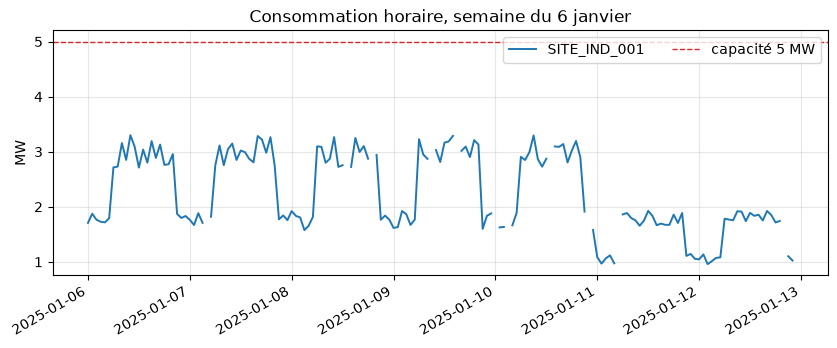

In [24]:
# === CELLULE 55 : Première courbe ===

# --- 1. Préparer le dossier de sortie (sans erreur s'il existe déjà)
Path("out").mkdir(exist_ok=True)

# --- 2. Sélectionner une semaine (6 au 12 janvier) d'un seul site : trois conditions combinées avec &
semaine = complet[(complet["site_id"] == "SITE_IND_001") & (complet["timestamp"] >= "2025-01-06") & (complet["timestamp"] < "2025-01-13")]

# --- 3. Créer la figure : fig = la toile, ax = le graphique dessiné dessus
fig, ax = plt.subplots(figsize=(10, 3.6))              # figsize : largeur x hauteur en pouces

# --- 4. Dessiner la courbe et le seuil de capacité
ax.plot(semaine["timestamp"], semaine["conso_mw"], color="#1f77b4", linewidth=1.4, label="SITE_IND_001")   # x = dates, y = consommation
ax.axhline(5.0, color="#d62728", linestyle="--", linewidth=1, label="capacité 5 MW")                        # ligne horizontale pointillée

# --- 5. Habillage : titre, unité, légende, grille, dates lisibles
ax.set_title("Consommation horaire, semaine du 6 janvier")
ax.set_ylabel("MW")                                    # unité de l'axe vertical
ax.legend(loc="upper right", ncol=2)                   # légende en haut à droite, sur 2 colonnes
ax.grid(alpha=0.3)                                     # grille discrète (30 % d'opacité)
fig.autofmt_xdate()                                    # incline les dates pour qu'elles ne se chevauchent pas

# --- 6. Enregistrer l'image : dpi = netteté, bbox_inches="tight" = pas de marge inutile
fig.savefig("out/fig_courbe.png", dpi=110, bbox_inches="tight")

### 💡 Interprétation : Cellule 55, matplotlib : figure, axe, courbe

- **Semaine ouvrée** : environ 3 MW le jour et 1,7 MW la nuit ; le **week-end** (11 et 12 janvier) est plus bas et plus plat, de 1 à 1,9 MW.
- **Interruptions** : les `NaN` ne sont pas tracés.
- **Ligne rouge** : la capacité de 5 MW, jamais approchée par ce site.
- **Approche objet** : `fig` et `ax` donnent un contrôle total.

## 📝 Cellule 56 : Plusieurs graphiques : `subplots` et axes partagés

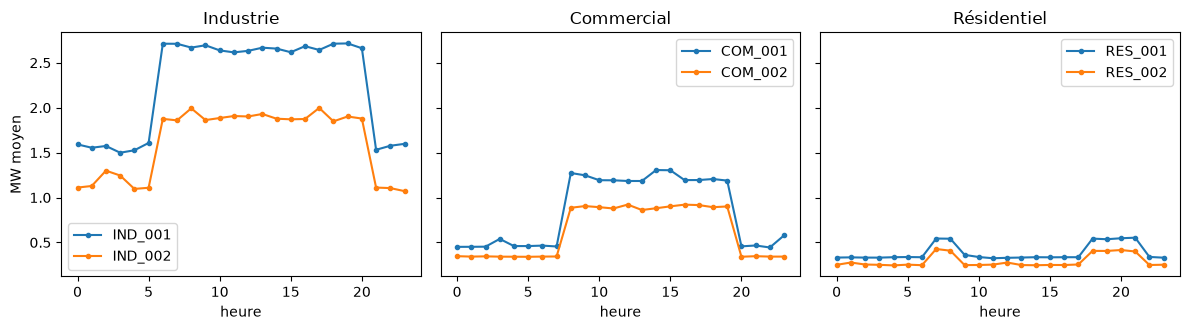

In [25]:
# === CELLULE 56 : Trois familles de sites ===

# --- 1. Regrouper les sites par famille : un dictionnaire {nom de la famille: liste de sites}
familles = {"Industrie": ["SITE_IND_001", "SITE_IND_002"],
            "Commercial": ["SITE_COM_001", "SITE_COM_002"],
            "Résidentiel": ["SITE_RES_001", "SITE_RES_002"]}

# --- 2. Créer 3 graphiques côte à côte (1 ligne, 3 colonnes)
#     sharey=True : même échelle verticale, pour comparer les familles honnêtement
#     axes est une liste de 3 graphiques, un par famille
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)

# --- 3. Remplir chaque graphique : zip associe un graphique à une famille
for ax, (nom, sites_famille) in zip(axes, familles.items()):
    for s in sites_famille:
        # profil = tableau heure x site de la cellule précédente ; marker="o" : un point par heure
        ax.plot(profil.index, profil[s], marker="o", markersize=3, label=s[-7:])   # s[-7:] : les 7 derniers caractères (ex. IND_001)
    ax.set_title(nom)                                  # titre du graphique = nom de la famille
    ax.set_xlabel("heure")
    ax.legend()

# --- 4. Finitions
axes[0].set_ylabel("MW moyen")                         # un seul libellé vertical, sur le graphique de gauche
fig.tight_layout()                                     # ajuste les marges pour éviter tout chevauchement
fig.savefig("out/fig_familles.png", dpi=110, bbox_inches="tight")

### 💡 Interprétation : Cellule 56, Plusieurs graphiques : `subplots` et axes partagés

- **`sharey=True`** : échelle commune, donc comparaison honnête entre familles.
- **Industrie** : de 1 à 2,7 MW ; **résidentiel** : moins de 0,6 MW.
- **`axes[0].set_ylabel`** : un seul libellé pour trois graphiques.

## 📝 Cellule 57 : seaborn : `lineplot` avec `hue`

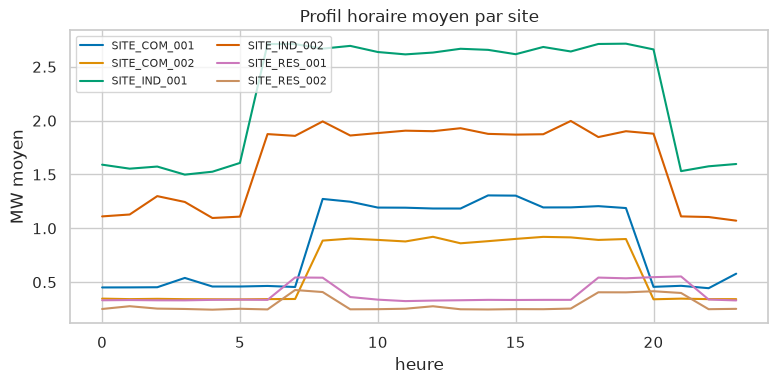

In [26]:
# === CELLULE 57 : lineplot ===

# --- 1. Style global de seaborn, valable pour tous les graphiques suivants
#     style="whitegrid" : fond blanc avec quadrillage ; palette="colorblind" : couleurs distinctes pour les daltoniens
sns.set_theme(style="whitegrid", palette="colorblind")

# --- 2. Une courbe par site, à partir du DataFrame au format long de la cellule précédente
fig, ax = plt.subplots(figsize=(9, 3.8))
#     x, y : les colonnes à placer sur les axes ; hue : une couleur (donc une courbe) par valeur de site_id
sns.lineplot(data=long, x="heure", y="mw_moyen", hue="site_id", ax=ax)

# --- 3. Habillage et enregistrement
ax.set_title("Profil horaire moyen par site")
ax.set_ylabel("MW moyen")
ax.legend(title="", fontsize=8, ncol=2)               # légende sur 2 colonnes, sans titre, en petits caractères
fig.savefig("out/fig_profils.png", dpi=110, bbox_inches="tight")

### 💡 Interprétation : Cellule 57, seaborn : `lineplot` avec `hue`

- **`hue="site_id"`** : une courbe par site, sans boucle.
- **Deux groupes visibles** : les gros sites en haut, les deux résidentiels en bas.
- **Palette `colorblind`** : lisible aussi pour les daltoniens.
- **Format long** : seaborn s'appuie sur les colonnes du DataFrame long.

## 📝 Cellule 58 : Distributions : `boxplot` et repérage des anomalies

{'SITE_COM_001': 5, 'SITE_IND_002': 5, 'SITE_RES_002': 3, 'SITE_COM_002': 1, 'SITE_RES_001': 1}


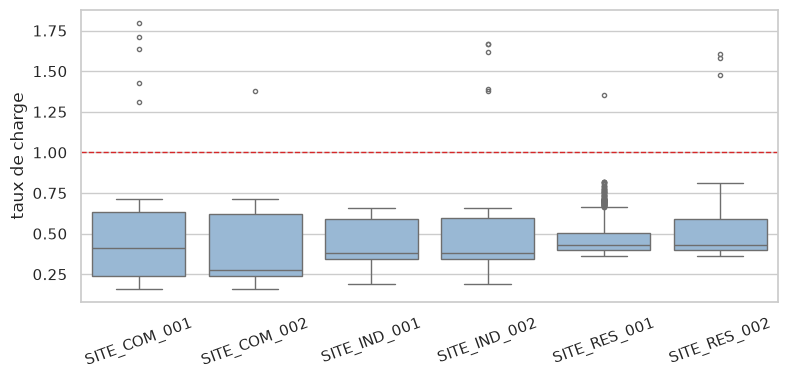

In [27]:
# === CELLULE 58 : boxplot ===

# --- 1. Créer la figure et son graphique
fig, ax = plt.subplots(figsize=(9, 3.8))

# --- 2. Une boîte par site : la boîte = 50 % des valeurs, la barre = médiane, les points = valeurs extrêmes
#     x = catégorie (site), y = valeur mesurée ; fliersize : taille des points extrêmes
sns.boxplot(data=complet, x="site_id", y="taux_charge", ax=ax, color="#8fb8de", fliersize=3)

# --- 3. Repère : ligne à 1 = 100 % de la capacité ; au-dessus, la mesure est physiquement impossible
ax.axhline(1, color="#d62728", linestyle="--", linewidth=1)

# --- 4. Habillage et enregistrement
ax.set_ylabel("taux de charge")
ax.set_xlabel("")                                      # pas de titre d'axe : les noms de sites suffisent
ax.tick_params(axis="x", labelrotation=20)             # noms des sites inclinés de 20 degrés
fig.savefig("out/fig_boxplot.png", dpi=110, bbox_inches="tight")

# --- 5. Compter les dépassements par site pour confirmer ce que montre le graphique
print(complet.loc[complet["taux_charge"] > 1, "site_id"].value_counts().to_dict())

### 💡 Interprétation : Cellule 58, Distributions : `boxplot` et repérage des anomalies

- **Points au-dessus de la ligne rouge** : les 15 pics aberrants (`SITE_COM_001` et `SITE_IND_002` : 5 chacun).
- **Médianes** : de 0,27 à 0,43 de la capacité.
- **`SITE_RES_001`** : le nuage entre 0,65 et 0,82 correspond aux pointes du soir, **normales** ; seule la ligne rouge (1,0) signale une anomalie.
- **`SITE_IND_001`** : aucun dépassement.

## 📝 Cellule 59 : Carte de chaleur : jour × heure

(30, 24)


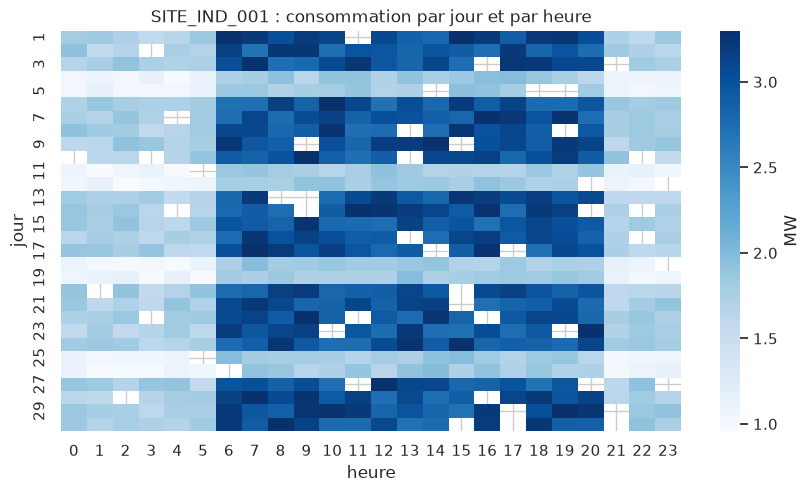

In [28]:
# === CELLULE 59 : heatmap ===

# --- 1. Ne garder qu'un site, et ajouter deux colonnes lues dans la date : le jour du mois et l'heure
un_site = complet[complet["site_id"] == "SITE_IND_001"].assign(
    jour=lambda d: d["timestamp"].dt.day,              # .dt.day : jour du mois (1 à 30)
    heure=lambda d: d["timestamp"].dt.hour)            # .dt.hour : heure (0 à 23)

# --- 2. Tableau jours (lignes) x heures (colonnes) ; chaque case = consommation moyenne du jour à cette heure
grille = un_site.pivot_table(index="jour", columns="heure", values="conso_mw", aggfunc="mean")

# --- 3. Dessiner : une couleur par case (plus foncé = plus forte consommation)
fig, ax = plt.subplots(figsize=(10, 5.2))
#     cmap="Blues" : dégradé de bleus ; cbar_kws : titre de la barre de couleurs ; les cases blanches sont des NaN
sns.heatmap(grille, cmap="Blues", cbar_kws={"label": "MW"}, ax=ax)
ax.set_title("SITE_IND_001 : consommation par jour et par heure")

# --- 4. Enregistrer, puis contrôler la forme du tableau
fig.savefig("out/fig_heatmap.png", dpi=110, bbox_inches="tight")
print(grille.shape)                                  # (30 jours, 24 heures)

### 💡 Interprétation : Cellule 59, Carte de chaleur : jour × heure

- **Cases blanches** : mesures manquantes (`NaN`).
- **Colonnes foncées** de 6 h à 20 h : les heures d'activité.
- **Lignes plus claires** : les week-ends (4-5, 11-12, 18-19, 25-26 janvier).

## 📝 Cellule 60 : Histogramme par famille de sites

{'Commercial': 0.275, 'Industrie': 0.383, 'Residentiel': 0.429}


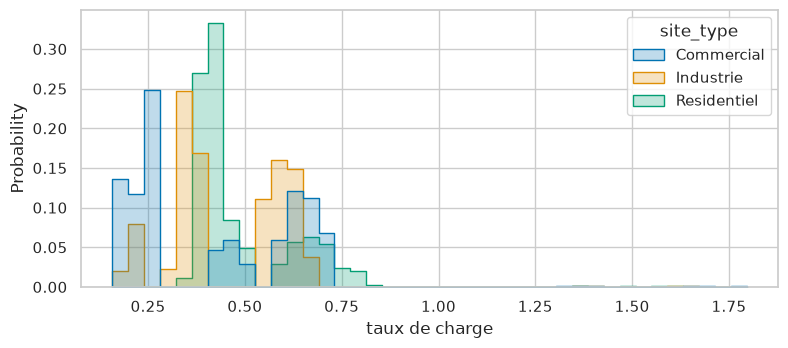

In [29]:
# === CELLULE 60 : histplot ===

# --- 1. Créer la figure
fig, ax = plt.subplots(figsize=(9, 3.6))

# --- 2. Histogramme du taux de charge, un par famille de sites
#     hue="site_type"       : une couleur par famille
#     bins=40               : 40 tranches de valeurs
#     element="step"        : contours plutôt que barres pleines (les familles se lisent même superposées)
#     stat="probability"    : hauteur = part des mesures (et non un simple compte)
#     common_norm=False     : chaque famille est ramenée à 100 % séparément, pour comparer leurs formes
sns.histplot(data=complet, x="taux_charge", hue="site_type", bins=40, element="step",
             stat="probability", common_norm=False, ax=ax)

# --- 3. Habillage et enregistrement
ax.set_xlabel("taux de charge")
fig.savefig("out/fig_histogramme.png", dpi=110, bbox_inches="tight")

# --- 4. Médiane du taux de charge par famille : la valeur « typique », insensible aux pics
print(complet.groupby("site_type", observed=True)["taux_charge"].median().round(3).to_dict())

### 💡 Interprétation : Cellule 60, Histogramme par famille de sites

- **Médianes du taux de charge** : commercial 0,275, industrie 0,383, résidentiel 0,429.
- **`common_norm=False`** : chaque famille est normalisée séparément.
- **`stat="probability"`** : compare des familles de tailles différentes.

## 📝 Cellule 61 : Exporter : CSV, Parquet et relecture

In [30]:
# === CELLULE 61 : Exports ===

# --- 1. Choisir les colonnes utiles, puis écrire dans deux formats
final = complet[["timestamp", "site_id", "site_type", "conso_mw", "taux_charge", "niveau"]]
final.to_csv("out/mesures_propres.csv", index=False, encoding="utf-8-sig")   # CSV : lisible dans Excel ; index=False : sans numéros de ligne
final.to_parquet("out/mesures_propres.parquet", index=False)                 # Parquet : binaire, typé et compressé

# --- 2. Comparer le poids des deux fichiers
for nom in ("mesures_propres.csv", "mesures_propres.parquet"):
    print(f"{nom:<25} {Path('out', nom).stat().st_size / 1024:7.0f} Ko")     # taille en octets / 1024 = Ko

# --- 3. Relire les deux fichiers : les types survivent-ils ?
lu_csv = pd.read_csv("out/mesures_propres.csv", encoding="utf-8-sig")
lu_pq = pd.read_parquet("out/mesures_propres.parquet")
print(lu_csv["timestamp"].dtype, "|", lu_pq["timestamp"].dtype)     # CSV : texte ; Parquet : vrai datetime
print(lu_pq["niveau"].dtype)                                        # la catégorie est conservée par Parquet

mesures_propres.csv           289 Ko
mesures_propres.parquet        41 Ko
str | datetime64[us]
category


### 💡 Interprétation : Cellule 61, Exporter : CSV, Parquet et relecture

- **CSV** : 289 Ko ; **Parquet** : 41 Ko, environ 7 fois moins.
- **CSV relu** : `timestamp` redevient du texte ; **Parquet** conserve `datetime64` et `category`.
- **Parquet** : format natif de Fabric et de Delta.
- **`pyarrow`** : installé pour cette raison dans `venv-data`.

# PARTIE 9 : DU POSTE LOCAL À FABRIC

Le code utile quitte le notebook : vous créez le module **à la main dans l'Explorateur Windows**, puis vous l'importez.

## 🖐️ Étape manuelle : Créer le module `qualite_pandas.py`

- **Même démarche** que `energie_utils.py` (Atelier 1) : le code utile quitte le notebook pour un fichier réutilisable.
- **Contenu** : `parser_dates`, `nettoyer` et `resume_sites`, issues des Cellules 42, 46 et 48.
- **Dépendance** : le module exige **pandas**, donc il ne s'importe que dans `venv-data`.
- **Emplacement** : à côté du notebook, dans le dossier de travail (Atelier 1, Cellule 50 : Python cherche d'abord dans ce dossier).

1. Ouvrez le dossier `formation_python_fabric` dans l'**Explorateur Windows**.
2. Affichez les extensions : onglet **Affichage** → cochez **Extensions de noms de fichiers**.
3. Clic droit dans le dossier → **Nouveau** → **Document texte**. Renommez-le **`qualite_pandas.py`** (confirmez le changement d'extension).
4. Clic droit sur le fichier → **Ouvrir avec** → **Bloc-notes**. Collez le contenu ci-dessous, puis **Ctrl + S**.
5. Vérifiez l'encodage : **Fichier → Enregistrer sous → Encodage : UTF-8**.

In [31]:
# Étape manuelle : les apprenants créent ce fichier dans l'Explorateur ; ici, création automatique.
with open('qualite_pandas.py', 'w', encoding='utf-8') as f:
    f.write('"""qualite_pandas.py — Nettoyage des mesures EnergiaNord avec pandas (Atelier 2)."""\nimport pandas as pd\n\nCODES = (-999, -888, -777)\nFORMATS = ("%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S")\n\n\ndef parser_dates(serie: pd.Series) -> pd.Series:\n    """Convertit des timestamps en 3 formats ; NaT si aucun format ne convient."""\n    resultat = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[us]")\n    for fmt in FORMATS:\n        resultat = resultat.fillna(pd.to_datetime(serie, format=fmt, errors="coerce"))\n    return resultat\n\n\ndef nettoyer(brut: pd.DataFrame) -> pd.DataFrame:\n    """Doublons exacts, dates, codes erreur en NaN, tri par site et date."""\n    return (\n        brut\n        .drop_duplicates()\n        .assign(\n            timestamp=lambda d: parser_dates(d["timestamp"]),\n            conso_mw=lambda d: d["conso_mw"].mask(d["conso_mw"].isin(CODES)),\n        )\n        .sort_values(["site_id", "timestamp"], ignore_index=True)\n    )\n\n\ndef resume_sites(propre: pd.DataFrame) -> pd.DataFrame:\n    """Mesures, valides, taux d\'anomalies et consommation moyenne par site."""\n    return propre.groupby("site_id", observed=True).agg(\n        mesures=("conso_mw", "size"),\n        valides=("conso_mw", "count"),\n        moyenne_mw=("conso_mw", "mean"),\n    ).assign(taux_anomalies=lambda d: (1 - d["valides"] / d["mesures"]).round(3)).round(3)\n')
print('qualite_pandas.py', ':', len(open('qualite_pandas.py', encoding='utf-8').read().splitlines()), 'lignes')

qualite_pandas.py : 35 lignes


## 📝 Cellule 62 : Importer et réutiliser le module

In [32]:
# === CELLULE 62 : Réutiliser qualite_pandas ===
import importlib, sys
from pathlib import Path

# --- 1. Préparer l'import : dossier de travail dans sys.path, et cache des dossiers rafraîchi
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))               # Python cherchera d'abord dans ce dossier
importlib.invalidate_caches()                         # le fichier vient d'être créé : Python doit re-scanner le dossier
print("qualite_pandas.py présent :", Path("qualite_pandas.py").exists(), "| dossier :", Path.cwd().name)   # doit afficher True

# --- 2. Importer votre module sous un nom court
import qualite_pandas as qp

# --- 3. Repartir du fichier brut, comme le ferait n'importe quel autre notebook
brut2 = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})

# --- 4. Appeler les fonctions du module : plus aucune étape de nettoyage écrite dans le notebook
propre2 = qp.nettoyer(brut2)                          # doublons, dates, codes erreur, tri : tout est dans la fonction
print(qp.resume_sites(propre2))                       # tableau récapitulatif par site
print(len(propre2), "lignes | module :", qp.__name__)   # __name__ : nom sous lequel le module est connu

qualite_pandas.py présent : True | dossier : nbrun_data
              mesures  valides  moyenne_mw  taux_anomalies
site_id                                                   
SITE_COM_001      720      654       0.847           0.092
SITE_COM_002      720      669       0.617           0.071
SITE_IND_001      720      670       2.254           0.069
SITE_IND_002      720      658       1.613           0.086
SITE_RES_001      720      647       0.387           0.101
SITE_RES_002      720      672       0.293           0.067
4320 lignes | module : qualite_pandas


### 💡 Interprétation : Cellule 62, Importer et réutiliser le module

- **Mêmes chiffres** que la Cellule 47 : 720 mesures par site, de 6,7 % à 10,1 % d'anomalies.
- **4 320 lignes** après nettoyage.
- **Réutilisation** : un autre notebook du dossier, avec ce noyau, l'importe sans rien copier.

## 📝 Cellule 63 : Envelopper un DataFrame avec __getattr__

In [33]:
# === CELLULE 63 : Un wrapper autour d'un DataFrame ===

# --- 1. La classe : un DataFrame à l'intérieur, une méthode métier à l'extérieur
class SuiviSite:
    def __init__(self, df):
        self._df = df                                     # le DataFrame enveloppé

    def __repr__(self):                                   # affichage court dans le notebook
        return f"SuiviSite({len(self)} mesures, {self._df['site_id'].nunique()} sites)"

    def __len__(self):
        return len(self._df)

    def __getitem__(self, cle):                           # suivi["conso_mw"], suivi[masque]... : délégué à pandas
        return self._df[cle]

    def __getattr__(self, nom):                           # appelée seulement si l'attribut n'existe pas ici
        if nom == "_df":                                  # évite une boucle infinie pendant la construction
            raise AttributeError(nom)
        return getattr(self._df, nom)                     # sinon : on demande au DataFrame

    def taux_anomalies(self):                             # méthode métier ajoutée par le wrapper
        return self._df["conso_mw"].isna().mean().round(3)

# --- 2. Utilisation sur le DataFrame nettoyé de la cellule précédente
suivi = SuiviSite(propre2)
print(suivi)                                              # __repr__
print(len(suivi), "|", suivi.shape)                       # __len__, puis .shape : délégué au DataFrame
print(suivi.taux_anomalies())                             # méthode du wrapper
print(suivi["conso_mw"].max())                            # __getitem__ délégué
print(suivi.head(2))                                      # .head() : jamais défini dans la classe

SuiviSite(4320 mesures, 6 sites)
4320 | (4320, 6)
0.081
5.846
            timestamp       site_id  conso_mw  voltage_v  frequency_hz status
0 2025-01-01 00:00:00  SITE_COM_001     0.458      234.8         49.87     OK
1 2025-01-01 01:00:00  SITE_COM_001       NaN      226.2         49.78  ERROR


### 💡 Interprétation : Cellule 63, Envelopper un DataFrame avec __getattr__

- **`suivi.shape` et `suivi.head()`** fonctionnent sans être écrits : `__getattr__` les transmet au DataFrame.
- **`taux_anomalies()`** : la logique métier vit dans la classe, pandas reste disponible dessous.
- **Usage réel** : wrapper d'un DataFrame de référence, ou d'un client d'API dont les méthodes sont déléguées.

## 📝 Cellule 64 : Un chargement portable : local et Fabric

In [34]:
# === CELLULE 64 : Chargement portable ===
from importlib.util import find_spec

# --- 1. Détecter l'environnement : le module notebookutils n'existe que dans Fabric
DANS_FABRIC = find_spec("notebookutils") is not None   # find_spec cherche le module sans l'importer (donc sans erreur)

# --- 2. Une seule fonction porte la différence entre les deux mondes
def charger_mesures(nom="consommation_30jours.csv") -> pd.DataFrame:
    # Dossier du Lakehouse dans Fabric, dossier data/ en local
    dossier = Path("/lakehouse/default/Files/data_python") if DANS_FABRIC else Path("data")
    # Le reste de la lecture est identique partout : c'est le but
    return pd.read_csv(dossier / nom, encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})

# --- 3. Utilisation : le code appelant ne change pas d'un environnement à l'autre
mesures = charger_mesures()
print(f"Dans Fabric : {DANS_FABRIC} | {len(mesures)} lignes | {len(qp.nettoyer(mesures))} après nettoyage")   # qp = module de la cellule précédente

Dans Fabric : False | 4365 lignes | 4320 après nettoyage


### 💡 Interprétation : Cellule 64, Un chargement portable : local et Fabric

- **Local** : `DANS_FABRIC` vaut `False`, la lecture vise `data/`.
- **Dans Fabric** : même fonction, chemin du Lakehouse `/lakehouse/default/Files/data_python/`.
- **Notebook Spark** : lire avec Spark, puis `toPandas()` si le volume le permet.
- **Isoler** : les différences d'environnement dans **une seule** fonction.